In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
from make import load_heathy_data
from pathlib import Path
import os

spec = load_heathy_data()


Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1

In [4]:
len(spec)

1372

In [5]:
from validation_util import split

#valid_spec = split(spec, int(len(spec) * 0.1))

In [6]:
print(f'Initial shape of a spectrogram: ', spec[0].shape)

ch, freq_bins = spec[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')

Initial shape of a spectrogram:  (33, 153)
Final shape: (33, 43)


In [88]:
# constants you can tweak once
FLOOR_DB   = -45.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [8]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import matplotlib

#custom_color_map = ListedColormap(["#F9F7ED", "#BAC8D3", "#647687"], name="custom_rgb_map")
#matplotlib.colormaps.register(name="custom_rgb_map", cmap=custom_color_map)

In [132]:
def get_x(i):
    arr = spec[i]  # (H, W) or (H, W, C)

    # If spectrogram is multi-channel, convert to single channel
    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
        t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    # Remove batch dimension, wrap as TensorImage
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

In [10]:
def get_x_validate(i):
    arr = valid_spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
            arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

In [133]:
block = DataBlock(
    blocks=(TransformBlock(), TransformBlock()),
    splitter=RandomSplitter(valid_pct=0.2),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_x,
    item_tfms=Resize(112)
)

In [134]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=16)

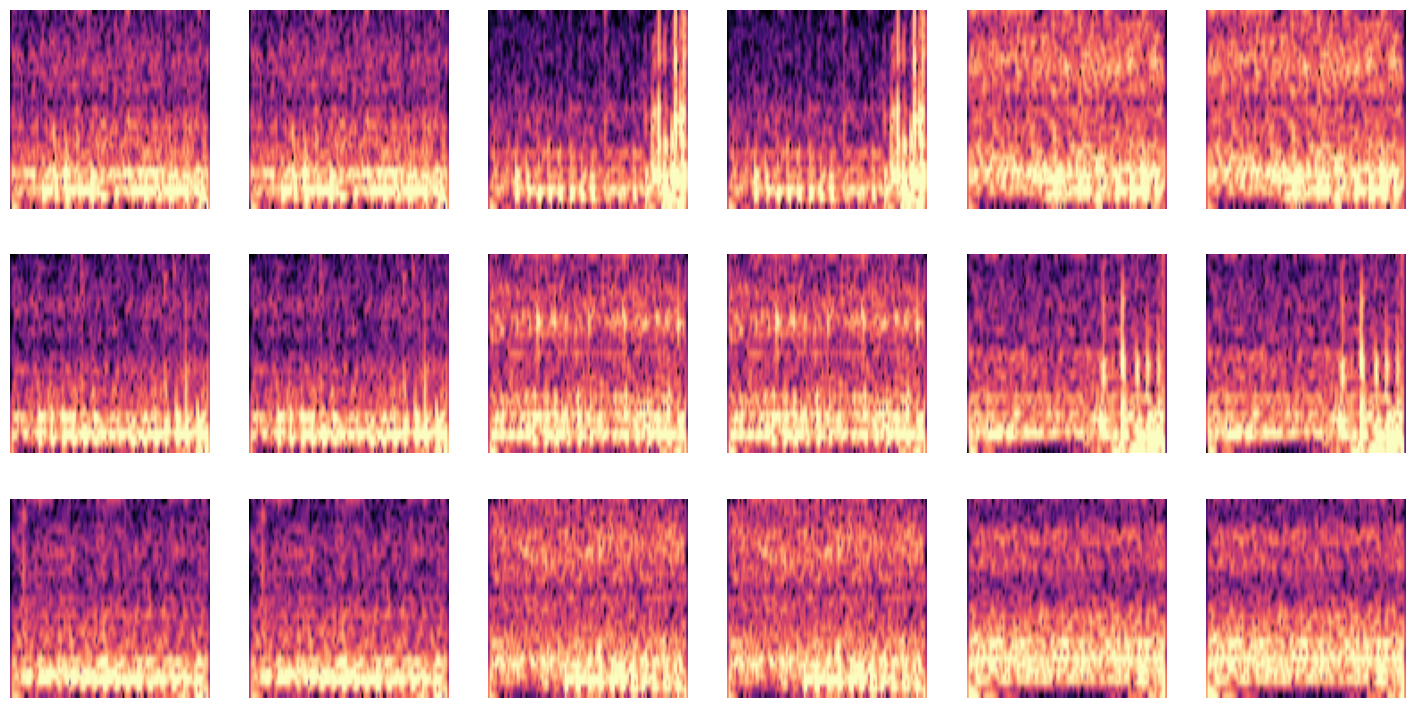

In [135]:
dls.show_batch()

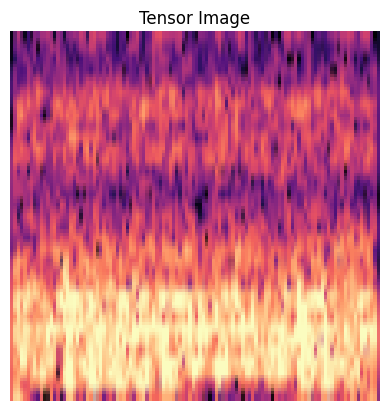

In [136]:
from plot_util import PlotUtil

PlotUtil.plot_tensor_image(get_x(5))

In [99]:
import torch
import torch.nn as nn


class Experimental(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        
        self.encoder = nn.Sequential(

            nn.Conv2d(3,12,4,stride=2,padding=1),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Conv2d(12,24,4,stride=2,padding=1),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Conv2d(24,48,4,stride=2,padding=1),
            nn.Dropout(0.1),
            nn.ReLU(),

        )

        self.enc_channels = 48
        self.enc_h = 14
        self.enc_w = 14

        enc_flat = self.enc_channels * self.enc_h * self.enc_w
    
    
        # ---------- Bottleneck ----------
        self.to_latent = nn.Sequential(
            nn.Flatten(),                     # [B,48,14,14] -> [B,9408]
            nn.Linear(enc_flat, latent_dim),  # Compress to tiny latent
            nn.ReLU(inplace=True),
        )

        self.from_latent = nn.Sequential(
            nn.Linear(latent_dim, enc_flat),  # Expand back
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (self.enc_channels, self.enc_h, self.enc_w)) # -> [B,48,14,14]
        )
    
        # ---------- Decoder ----------
        self.decoder = nn.Sequential(
    
            nn.ConvTranspose2d(48,24,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(24,12,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(12,3,4,stride=2,padding=1),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        encoder = self.encoder(x)
        z = self.to_latent(encoder)
        z_feat = self.from_latent(z)
        decoder = self.decoder(z_feat)
        return decoder
    
    def to_device(self, device):
        """Move model to specified device"""
        self.to(device)
        return self
    
    @property
    def device(self):
        """Get the device the model is on"""
        return next(self.parameters()).device

In [100]:
autoencoder = Experimental()

In [101]:
learn = False

In [137]:
learn = Learner(dls, autoencoder, loss_func=F.mse_loss)


In [17]:
learn.fine_tune(50)

epoch,train_loss,valid_loss,time
0,0.150757,0.103902,00:01


epoch,train_loss,valid_loss,time
0,0.098211,0.095618,00:01
1,0.093686,0.089794,00:01
2,0.087704,0.083817,00:01
3,0.083591,0.081380,00:01
4,0.081298,0.079804,00:01
5,0.079625,0.078694,00:01
6,0.078453,0.077735,00:01
7,0.077401,0.076726,00:01
8,0.076389,0.076227,00:01
9,0.075609,0.075616,00:01


In [18]:
learn.unfreeze()

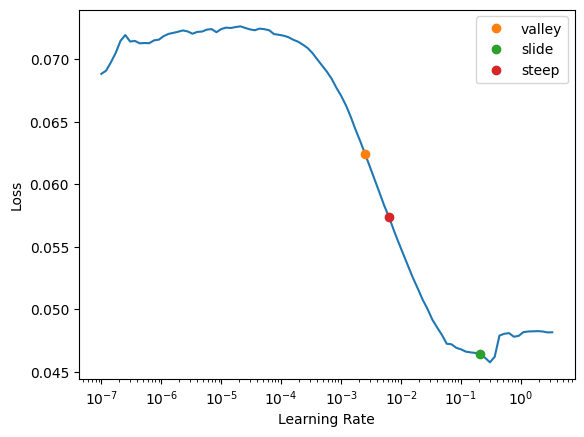

In [138]:
lr = learn.lr_find(suggest_funcs=(valley,slide,steep))

In [139]:
learn.fit_one_cycle(n_epoch = 200, lr_max=lr.valley)

epoch,train_loss,valid_loss,time
0,0.048288,0.038146,00:01
1,0.033288,0.024193,00:01
2,0.022929,0.017662,00:01
3,0.017911,0.015535,00:01
4,0.015728,0.014562,00:01
5,0.014635,0.013976,00:01
6,0.014029,0.013573,00:01
7,0.013601,0.013224,00:01
8,0.013221,0.012961,00:01
9,0.013004,0.012800,00:01


In [140]:
learn.validate()

(#1) [0.01076333038508892]

In [205]:
dir = Path('./models')

In [206]:

learn.path = dir

learn.export('autoencoder.pkl')

In [6]:
learn = load_learner(dir/'autoencoder.pkl')

/media/Delta/code/Master/Master-project/vibration_model/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


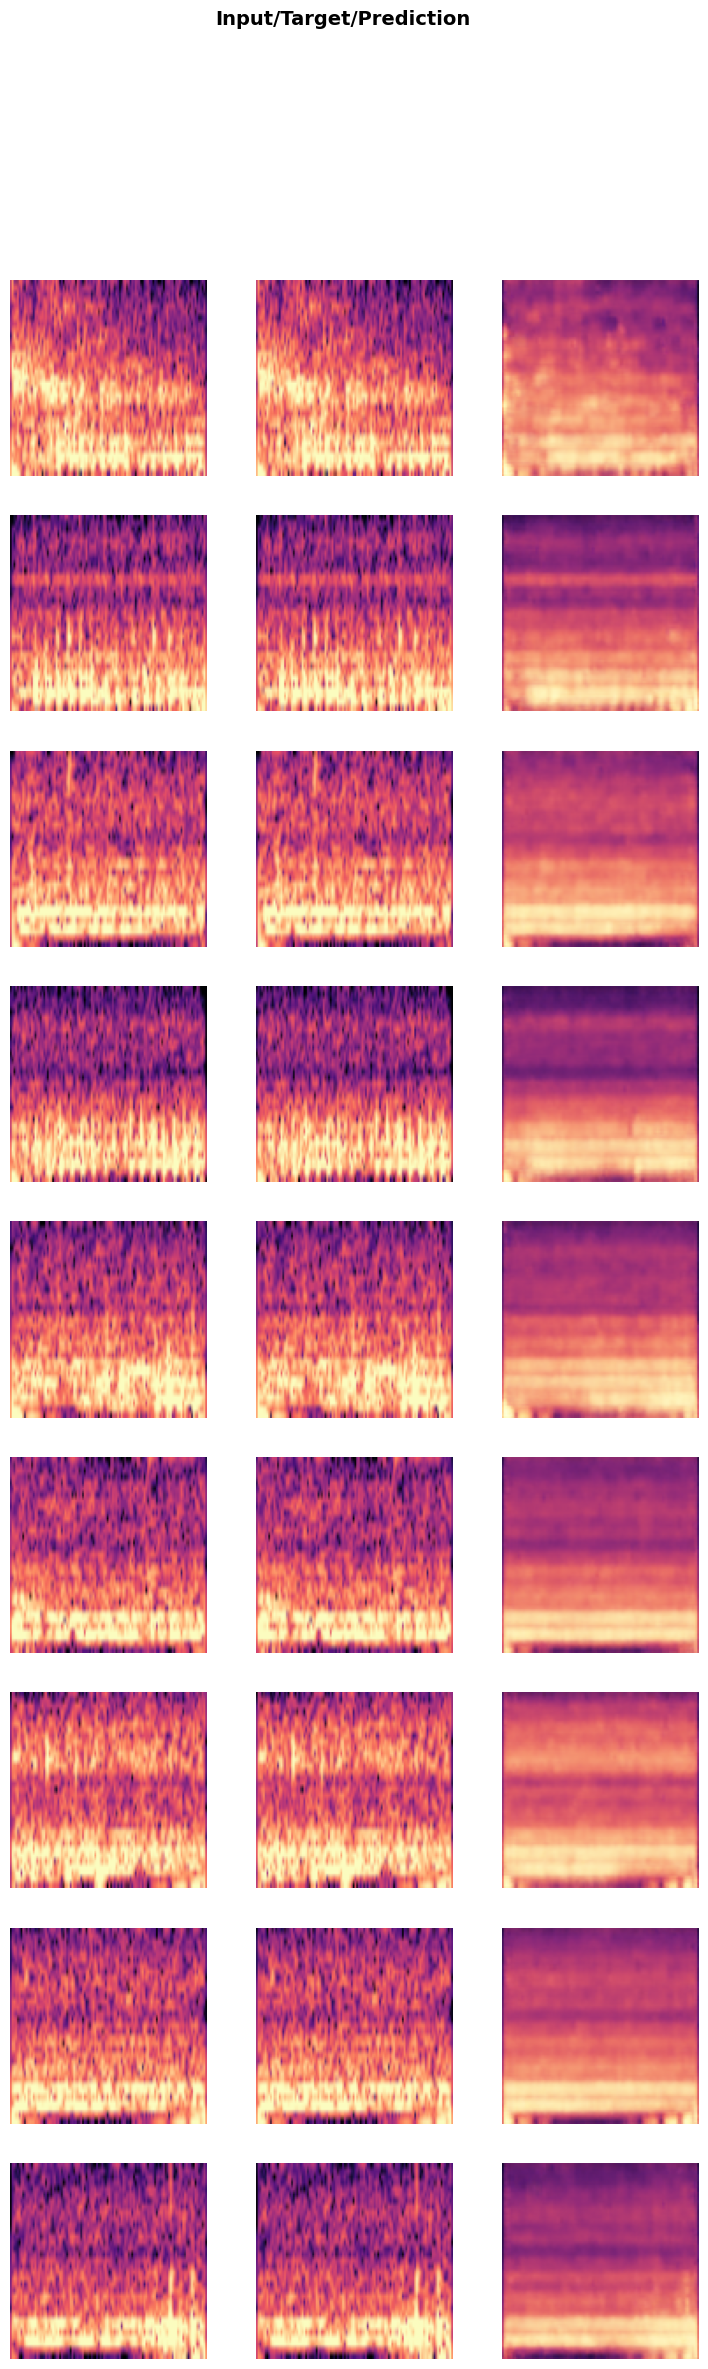

In [142]:
learn.show_results()

In [107]:
from make import load_test_data, load_primary_data
from validation_util import get_label_index

test_spec, test_labels = load_test_data()

Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: F

In [8]:
get_label_index("Fall", test_labels)

0

In [143]:
def get_x_test(i):
    arr = test_spec[i]

    # If spectrogram is multi-channel, convert to single channel
    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
        t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    # Remove batch dimension, wrap as TensorImage
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y_test(i):
      return test_labels[i]

In [144]:

block = DataBlock(
    blocks=(TransformBlock(), TransformBlock()),
    get_items=lambda x: x,
    splitter=None,
    get_x=get_x_test,
    get_y=get_x_test,
    item_tfms=Resize(112)
)

eval_block = DataBlock(
    blocks=(TransformBlock(), TransformBlock()),
    get_items=lambda x: x,
    splitter=None,
    get_x=get_x_test,
    get_y=get_y_test,
    item_tfms=Resize(112)
)

In [145]:
items = list(range(len(test_spec)))   # or `range(N)`
test_dls = block.dataloaders(items, bs=16)

eval_dls = eval_block.dataloaders(items, bs=16)

In [146]:
preds, targets, inputs = learn.get_preds(dl=test_dls.train, with_input=True, reorder=False)

In [147]:
preds.shape

torch.Size([327, 3, 112, 112])

In [148]:
targets.shape

torch.Size([327, 3, 112, 112])

In [149]:
inputs.shape

torch.Size([327, 3, 112, 112])

In [150]:
F.mse_loss(preds, targets)

TensorImage(0.0164)

In [151]:
F.l1_loss(preds, targets)

TensorImage(0.0857)

In [152]:
from kornia.metrics import psnr

psnr_value = psnr(preds, targets, max_val=1.0)

In [153]:
psnr_value

TensorImage(17.8499)

In [154]:
from validation_util import get_label_index

In [155]:
get_label_index("Fall", test_labels)

0

In [156]:
get_y_test(0)

'Fall'

In [157]:
pred_tensor = learn.predict(get_x_test(0))[0]

<Axes: >

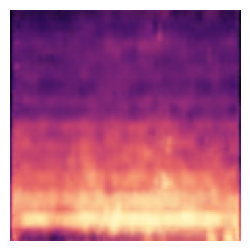

In [158]:
pred_tensor.show()

In [159]:
F.mse_loss(pred_tensor, get_x_test(0))

TensorImage(0.0161)

In [125]:
from plot_util import PlotUtil

pu = PlotUtil(test_spec)

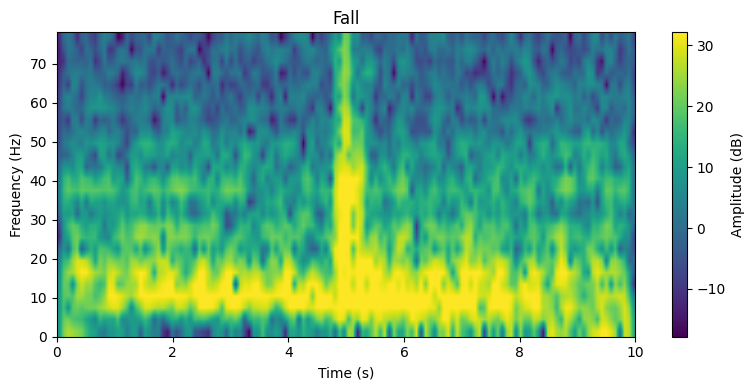

In [126]:
pu.show_spec(0, "Fall")

<Axes: >

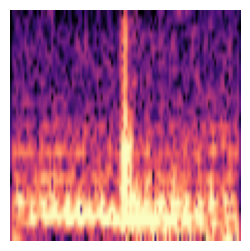

In [161]:
get_x_test(0).show()

In [162]:
psnr(pred_tensor, get_x_test(0), max_val=1.0)

TensorImage(17.9352)

In [163]:
len(test_spec)

408

In [164]:
# unwrap like before
x = targets[0] if isinstance(targets, (list, tuple)) else targets
if isinstance(preds, (list, tuple)): preds = preds[0]
x = x.float().to(preds.device); preds = preds.float()

# per-sample MSE
recon_error = ((x - preds)**2).flatten(1).mean(1).cpu().numpy()

In [165]:
recon_error

array([0.01529627, 0.01755025, 0.01735212, 0.01929446, 0.01126498,
       0.02299997, 0.01195451, 0.01563578, 0.02531167, 0.02420478,
       0.01863035, 0.01894031, 0.03411653, 0.01062033, 0.01040268,
       0.01139784, 0.01591938, 0.02762741, 0.01153449, 0.02507185,
       0.01297809, 0.01434139, 0.02145946, 0.01044191, 0.01462566,
       0.01186106, 0.01396212, 0.01331189, 0.01121421, 0.01497038,
       0.01297874, 0.01705032, 0.02523758, 0.02418151, 0.02782754,
       0.01870395, 0.012891  , 0.01168262, 0.01446028, 0.01176539,
       0.02328896, 0.02130817, 0.0130443 , 0.02864191, 0.01150187,
       0.0114513 , 0.010459  , 0.01187264, 0.02297834, 0.01128681,
       0.01126917, 0.01089542, 0.01327179, 0.02262026, 0.01941457,
       0.02485764, 0.0130291 , 0.01036707, 0.01227244, 0.0198121 ,
       0.01214933, 0.01038441, 0.02887447, 0.0131597 , 0.01136916,
       0.02675056, 0.01217752, 0.02779733, 0.011559  , 0.01013617,
       0.01231102, 0.01024711, 0.01227269, 0.01242734, 0.01489

In [166]:
len(recon_error)

327

In [35]:
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def show_channelwise_reconstruction(model, dl, n=3, channels=(5, 6, 7)):
    """
    Visualize original vs reconstructed spectrograms for specific channels.
    
    Parameters:
        model: Trained autoencoder
        dl: DataLoader
        n: Number of samples to show
        channels: Tuple of channel indices to visualize (e.g., (0, 1, 2))
    """
    model.eval()
    xb, _ = next(iter(dl))
    xb = xb[:n].to(device)
    with torch.no_grad():
        recon = model(xb)
    
    xb = xb.cpu()
    recon = recon.cpu()
    
    for ch in channels:
        plt.figure(figsize=(n * 3, 6))
        for i in range(n):
            # Original
            plt.subplot(2, n, i + 1)
            plt.imshow(xb[i, ch], aspect='auto', cmap='jet')
            plt.title(f"Orig (ch {ch})")
            plt.axis('off')
            
            # Reconstructed
            plt.subplot(2, n, n + i + 1)
            plt.imshow(recon[i, ch], aspect='auto', cmap='jet')
            plt.title(f"Recon (ch {ch})")
            plt.axis('off')

        plt.tight_layout()
        plt.show()
show_channelwise_reconstruction(learn.model, dls.valid, n=2, channels=(0,1,2))

NameError: name 'dls' is not defined

In [36]:
def show_rgb_reconstruction(model, dl, n=3, Fault=False, figname='orig_recon'):
    model.eval()
    xb, _ = next(iter(dl))
    xb = xb[:n].to(next(model.parameters()).device)

    with torch.no_grad():
        recon = model(xb)

    xb = xb.cpu().numpy()
    recon = recon.cpu().numpy()

    for i in range(n):
        fig, axs = plt.subplots(1, 2, figsize=(10, 6))
        axs[0].imshow(np.transpose(xb[i], (1, 2, 0)))  # (C, H, W) → (H, W, C)
        if Fault:
            axs[0].set_title("Faulty")
        else:
            axs[0].set_title("Healthy")
        axs[0].axis('off')
        axs[1].imshow(np.transpose(recon[i], (1, 2, 0)))
        axs[1].set_title("Reconstruction")
        axs[1].axis('off')
        plt.tight_layout()
        #plt.savefig(figname)
        plt.show()

show_rgb_reconstruction(learn.model, dls.valid, n=1, figname='healthy_rec')
#show_rgb_reconstruction(learn.model, test_dls, n=1, Fault=True, figname='missing_rec')

NameError: name 'dls' is not defined

In [37]:
def get_anomaly_scores(model, dataloader):
    model.eval()
    scores = []
    with torch.no_grad():
        for xb, _ in dataloader:
            xb = xb.to(device)
            recon = model(xb)
            err = F.mse_loss(recon, xb, reduction='none')  # (B, 3, 224, 224)
            score = err.mean(dim=(1, 2, 3))  # (B,)
            scores.extend(score.cpu().numpy())
    return scores

train_scores = get_anomaly_scores(learn.model, dls.train)
val_scores   = get_anomaly_scores(learn.model, dls.valid)

NameError: name 'dls' is not defined

In [167]:
from sklearn.metrics import classification_report

# Shared helper: prepare scores, labels, threshold, and preds for a class
def get_scores_and_preds(target_class, healthy_scores, errors_by_class, thresh_pctl=70):
    faulty_scores = np.asarray(errors_by_class[target_class], dtype=float)
    if faulty_scores.size == 0:
        return None  # caller can skip

    healthy_scores = np.asarray(healthy_scores, dtype=float)
    all_scores = np.concatenate([healthy_scores, faulty_scores])
    labels = np.array([0] * len(healthy_scores) + [1] * len(faulty_scores))
    thr_value = np.percentile(healthy_scores, thresh_pctl)
    preds = (all_scores > thr_value).astype(int)
    return {
        "all_scores": all_scores,
        "labels": labels,
        "thr_value": float(thr_value),
        "preds": preds
    }

# Small helper to split "Fault_Thing_High" -> ("Fault_Thing", "High")
def parse_fault_and_severity(cls_name):
    parts = cls_name.split("_")
    if parts and parts[-1] in {"Low", "Medium", "High", "None"}:
        return "_".join(parts[:-1]), parts[-1]
    return cls_name, "None"

def build_results(healthy_scores, errors_by_class, thresh_pctl=70, skip_names=("healthy","normal")):
    results = {}  # results[fault_type][severity] = metrics dict
    for cls, _scores in errors_by_class.items():
        if cls.lower() in skip_names:
            continue

        pack = get_scores_and_preds(cls, healthy_scores, errors_by_class, thresh_pctl=thresh_pctl)
        if pack is None:
            continue

        report = classification_report(pack["labels"], pack["preds"], output_dict=True)
        metrics = {
            "precision": report["1"]["precision"] * 100,
            "recall":    report["1"]["recall"]    * 100,
            "f1-score":  report["1"]["f1-score"]  * 100,
            "accuracy":  report["accuracy"]       * 100
        }

        fault_type, severity = parse_fault_and_severity(cls)
        results.setdefault(fault_type, {})[severity] = metrics

    return results


In [168]:
eval_dls.vocab = ["Not Fall", "Fall"]

label_to_idx = {v: i for i, v in enumerate(eval_dls.vocab)}

In [169]:
from sklearn.metrics import roc_curve, roc_auc_score

# Put model in eval mode
learn.model.eval()

recon_errors = []
y_true = []


with torch.no_grad():
    for xb, yb in eval_dls.train:
        xb = xb.to(learn.dls.device)
        preds = learn.model(xb)
        # Reconstruction error (MSE per sample)
        err = torch.mean((preds - xb)**2, dim=[1,2,3]).cpu().numpy()
        recon_errors.extend(err)
        # convert label batch to numeric
        if isinstance(yb, torch.Tensor):
            yb = yb.cpu().numpy().astype(int)
        else:
            yb = np.array([label_to_idx[str(l)] for l in yb])

        y_true.extend(yb)

recon_errors = np.array(recon_errors)
y_true = np.array(y_true)

In [170]:
len(recon_errors)

320

In [171]:
len(y_true)

320

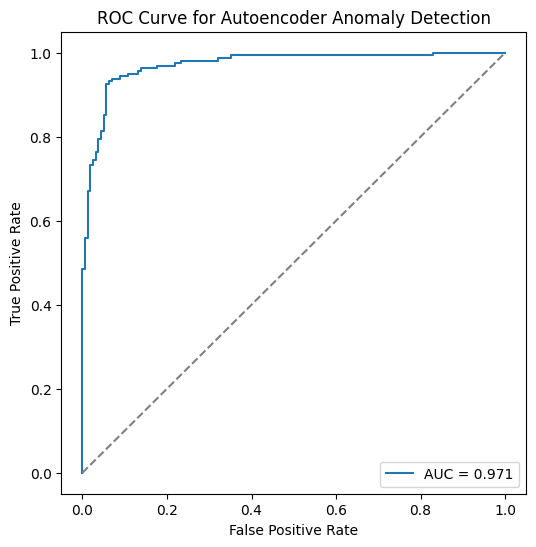

In [172]:
fpr, tpr, thresholds = roc_curve(y_true, recon_errors)
auc_score = roc_auc_score(y_true, recon_errors)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Autoencoder Anomaly Detection")
plt.legend()
plt.show()

In [173]:
J = tpr - fpr
idx = np.argmax(J)
optimal_threshold_yj = thresholds[idx]
print(f"Optimal threshold (Youden's J): {optimal_threshold_yj:.4f}")
print(f"TPR: {tpr[idx]:.3f}, FPR: {fpr[idx]:.3f}")

Optimal threshold (Youden's J): 0.0141
TPR: 0.925, FPR: 0.057


In [174]:
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds_pr = precision_recall_curve(y_true, recon_errors)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
idx = np.argmax(f1)
optimal_threshold_f1 = thresholds_pr[idx]
print(f"Best F1 threshold: {optimal_threshold_f1}")

Best F1 threshold: 0.013841693289577961


In [ ]:
threshold_50 = np.percentile(recon_error, 50)

threshold_95 = np.percentile(recon_error, 95)

threshold_30 = np.percentile(recon_error, 30)

def test_normal() -> list:
    result = []
    for i in range(len(test_spec)):
        if test_labels[i] == "Not Fall":
            result.append(F.mse_loss(get_x_test(i), learn.predict(get_x_test(i))[0]))

    return result

def test_anomaly() -> list:
    result = []
    for i in range(len(test_spec)):
        if test_labels[i] == "Fall":
            result.append(F.mse_loss(get_x_test(i), learn.predict(get_x_test(i))[0]))
    
    return result

def test_detections() -> list:
    result = []
    for i in range(len(test_spec)):
        result.append(F.mse_loss(get_x_test(i), learn.predict(get_x_test(i))[0]))
    
    return result

rcon_err_faulty = test_anomaly()
rcon_err_norm = test_normal()

detections = test_detections()

rcon_err_faulty


[TensorImage(0.0161),
 TensorImage(0.0134),
 TensorImage(0.0131),
 TensorImage(0.0171),
 TensorImage(0.0156),
 TensorImage(0.0158),
 TensorImage(0.0155),
 TensorImage(0.0170),
 TensorImage(0.0151),
 TensorImage(0.0140),
 TensorImage(0.0127),
 TensorImage(0.0149),
 TensorImage(0.0204),
 TensorImage(0.0179),
 TensorImage(0.0164),
 TensorImage(0.0201),
 TensorImage(0.0172),
 TensorImage(0.0157),
 TensorImage(0.0143),
 TensorImage(0.0171),
 TensorImage(0.0193),
 TensorImage(0.0193),
 TensorImage(0.0160),
 TensorImage(0.0186),
 TensorImage(0.0199),
 TensorImage(0.0182),
 TensorImage(0.0161),
 TensorImage(0.0174),
 TensorImage(0.0198),
 TensorImage(0.0181),
 TensorImage(0.0176),
 TensorImage(0.0203),
 TensorImage(0.0153),
 TensorImage(0.0145),
 TensorImage(0.0130),
 TensorImage(0.0159),
 TensorImage(0.0183),
 TensorImage(0.0167),
 TensorImage(0.0164),
 TensorImage(0.0183),
 TensorImage(0.0154),
 TensorImage(0.0155),
 TensorImage(0.0145),
 TensorImage(0.0150),
 TensorImage(0.0280),
 TensorIma

In [176]:
threshold_50

np.float32(0.013362536)

In [ ]:
def get_dr(threshold):
    pred_result = []
    for j in range(len(detections)):
        if detections[j] >= threshold:
            pred_result.append("Fall")
        else: pred_result.append("Not Fall")
    
    return pred_result

pred_result_f1 = get_dr(threshold=optimal_threshold_f1)
pred_result_youdens = get_dr(threshold=optimal_threshold_yj)
pred_result_50 = get_dr(threshold=threshold_50)
pred_result_95 = get_dr(threshold=threshold_95)
pred_result_30 = get_dr(threshold=0.073)

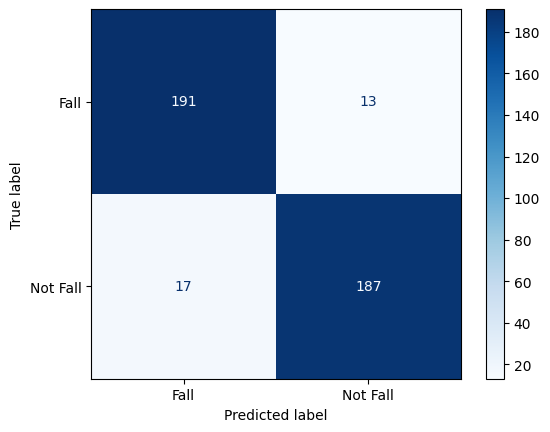

In [178]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
y_true = test_labels
cm = confusion_matrix(y_true, pred_result_f1)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fall", "Not Fall"])
disp.plot(cmap="Blues")  # customize as you like
plt.show()

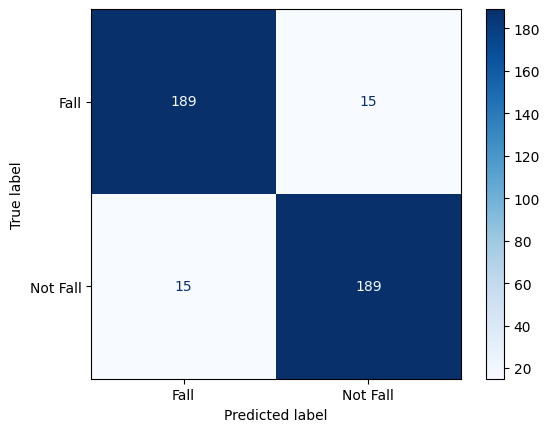

In [180]:
cm = confusion_matrix(y_true, pred_result_youdens)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fall", "Not Fall"])
disp.plot(cmap="Blues")  # customize as you like
plt.show()

## Filtering Rate 

### 0.073 threshod

Fall recall = 0.92
Filtering rate = 0.38

In [181]:
accuracy_f1 = accuracy_score(y_true, pred_result_f1)

In [182]:
accuracy_f1

0.9264705882352942

In [183]:
precision_score(y_true, pred_result_f1, average='weighted')

0.9266346153846154

In [184]:
recall_score(y_true, pred_result_f1, average='macro')

0.9264705882352942

In [185]:
optimal_f1 = f1_score(y_true, pred_result_f1, average='macro')

In [186]:
optimal_f1

0.9264635201384217

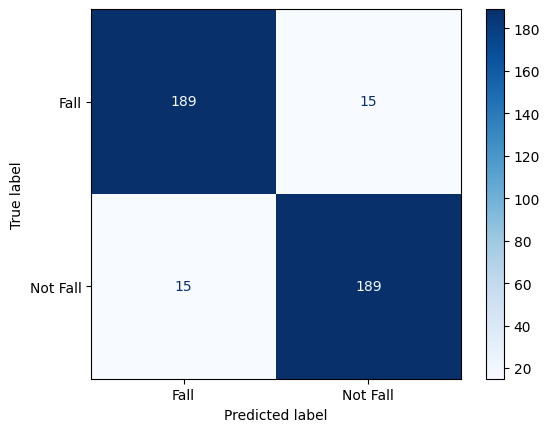

In [187]:
cm = confusion_matrix(y_true, pred_result_youdens)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fall", "Not Fall"])
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [188]:
accuracy_youdens = accuracy_score(y_true, pred_result_youdens)

In [189]:
accuracy_youdens

0.9264705882352942

In [190]:
precision_score(y_true, pred_result_youdens, average='weighted')

0.9264705882352942

In [191]:
recall_score(y_true, pred_result_youdens, average='weighted')

0.9264705882352942

In [192]:
youdens_f1 = f1_score(y_true, pred_result_youdens, average='weighted')

In [193]:
youdens_f1

0.9264705882352942

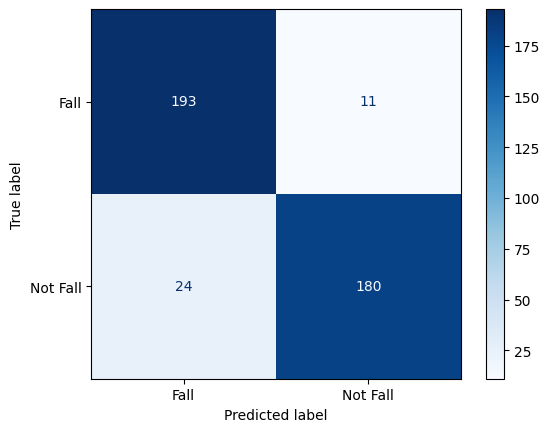

In [194]:
cm = confusion_matrix(y_true, pred_result_50)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fall", "Not Fall"])
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [195]:
accuracy_50_precentile = accuracy_score(y_true, pred_result_50)

In [196]:
f1_50_precentile = f1_score(y_true, pred_result_50, average='weighted')

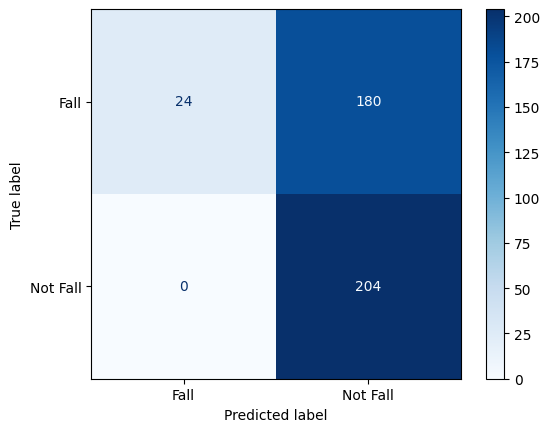

In [197]:
cm = confusion_matrix(y_true, pred_result_95)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fall", "Not Fall"])
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [198]:
accuracy_95_precentile = accuracy_score(y_true, pred_result_95)

In [199]:
f1_95_precentile = f1_score(y_true, pred_result_95, average='weighted')

In [200]:
def get_detection_rate(threshold):
    i = 0
    for j in range(len(rcon_err_faulty)):
        if rcon_err_faulty[j] >= threshold:
            i += 1
    
    return i / len(rcon_err_faulty)

def test(input : Tensor):
    input_mse = F.mse_loss(input, learn.predict(input)[0])
    if input_mse > optimal_threshold_f1:
        return "Fall"
    
    return "Not Fall"

In [201]:
get_detection_rate(optimal_threshold_f1)

0.9362745098039216

In [202]:
get_detection_rate(optimal_threshold_yj)

0.9264705882352942

In [203]:
thresholds_precentiles = ["F1", "Youden's J", "50 Percentile", "95 Percentile"]
accuracy = [accuracy_f1, accuracy_youdens, accuracy_50_precentile, accuracy_95_precentile]
f1_score = [optimal_f1, youdens_f1, f1_50_precentile, f1_95_precentile]

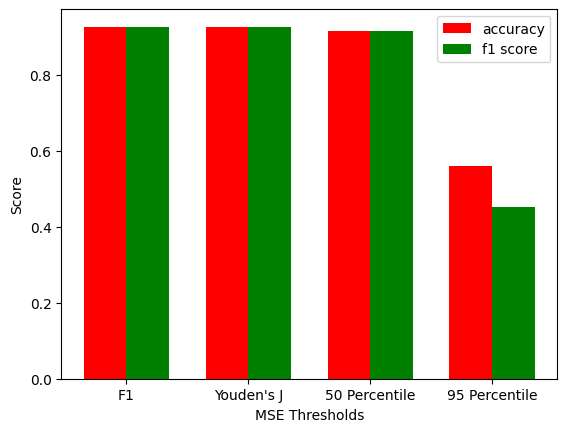

In [204]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(thresholds_precentiles))      # [0,1,2]
width = 0.35                    # width of each bar

plt.bar(x - width/2, accuracy, width=width, color='red', label="accuracy")
plt.bar(x + width/2, f1_score, width=width, color='green', label="f1 score")

plt.xlabel("MSE Thresholds"),
plt.ylabel("Score")
plt.xticks(x, thresholds_precentiles)
plt.legend()
plt.show()

## Reconstrcution 
- The Peak signal to noise ratio (psnr) is a metric that shows how well the model can reconstruct details.
- The psnr is low, indicating that the model cannot reconstruct the images very well.
- mse (mean squared error) is a metric to see how far from the origional the reconstruction is. 
- As there is no difference in the mse from reconstructing heathly vs unhealthy images is a key
- We see that the psnr is low, it fails to reconstruct the input accurately, indicating that the model did not learn to reconstruct the healty data.
- Reason: Theory is a too narrow dataset, with too much variation. Not a good fit for this application. 

- The samples in the dataset are too similary for the autoencoder to work. The difference should be more significant. The healthy data should also have a clear patterns, and if there is more patterns defined as healthy, the dataset should be larger to capture this. The "anomalies" is just interperted as more clumsy versions of the motions it has already seen.  

- Using supervised learning features the small differences, while the autoencoder attempts to recreate them as good as possible. The more events that is considered healthy, the more samples you need. 